In [18]:

import numpy as np

from Kea.statistics.spectra import per_spectra, spectra_base, strfn_spectra
from Kea.statistics.statfunc import statfunc_base, strfn
from Kea.statistics import statistics_base
from Kea.utils import plotting, data_writer

import sympy as sp

import h5py as h5

import time

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plotting.modify_rc()

twopi = 2.*np.pi

_N = 28955151
_L = 2663874.1129102707

grid_dims = (_N,)
phys_dims = (_L,)


In [19]:

def calc_sf(l, sf, grid_dims, phys_dims, num_bins=16, log_space=True):
    N = grid_dims[0]
    L = phys_dims[0]
    dx = L/N
    l_b, sf2_b, _ = statistics_base.bin_data(
        l, sf, bin_func=np.nanmean,
        bin_loc='true_center', log_space=log_space, min_bin=dx,# max_bin=L/2.,
        num_bins=num_bins)
    return (l, sf), (l_b, sf2_b)

def plot_sf(raw, binned, title=None):
    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))
    ax.plot(raw[0], raw[1], linestyle='-', color='red', linewidth=0.75, label='Raw')
    ax.plot(binned[0], binned[1], linestyle='--', color='blue', linewidth=0.75, label='Binned')

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km
    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.axvline(lc/U, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(lc/U, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.axvline(ri/U, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(ri/U, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)
    ax.set_xlabel(r'Time-scale, $\tau$ [s]')
    ax.set_ylabel(r'SF, $S_2(\tau)$ [nT$^2$]')
    ax.legend(fancybox=False)
    ax.set_title(title)


In [20]:
def plot_spec(raw, binned, title=None):

    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

    ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    #ax.plot(k[1:], fek_ss, linewidth=0.75, zorder=0, label='Smoothed', color='gray')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax.plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax.plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    for axx in [ax]:
        axx.set_yscale('log')
        axx.set_xscale('log')
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax.legend(frameon=True, fancybox=False, loc='lower left')

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km

    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

    ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

    ax.text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    ax.text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
    ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

    fig.align_ylabels()


In [21]:

from scipy.interpolate import interp1d
def interpolate(x, y, x_interp):
    f_int = interp1d(np.log10(x), y, kind='linear', fill_value='extrapolate')
    fek_new = f_int(np.log10(x_interp))
    return fek_new


In [22]:

def plot_spectra_and_bias(feko0, feko1, fekb1, fekb2, fekb3, title=None):

    fig = plt.figure(dpi=256, figsize=(3.5, 2.625))
    gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[1, 0.5], figure=fig, hspace=0., wspace=0.05)
    ax = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

    ax[0].plot(feko1[0], feko1[1], linestyle='-', linewidth=0.5, alpha=0.35, label='Raw')
    ax[0].plot(feko0[0], feko0[1], color='gray', linestyle='-', linewidth=0.75, label='Binned')

    ax[0].plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax[0].plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax[0].plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')


    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax[0].plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax[0].plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km

    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax[0].axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax[0].text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

    ax[0].axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax[0].text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

    ax[0].text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    ax[0].text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].yaxis.set_ticks_position('both')
    ax[0].xaxis.set_ticks_position('both')
    ax[0].tick_params(axis='y', direction='in')
    ax[0].tick_params(axis='y', direction='in', which='minor')
    ax[0].tick_params(axis='x', direction='in')
    ax[0].tick_params(axis='x', direction='in', which='minor')
    ax[0].grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    #ax.set_xlabel(r'Wavenumber, $k$ [inv. length]')
    ax[0].set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
    ax[0].set_xticklabels([])

    #max_v = np.nanmax([np.nanmax(feko1[1]), np.nanmax(fekb1[1]), np.nanmax(fekb2[1]), np.nanmax(fekb3[1])])
    #min_v = feko[1][-1]
    #min_v = np.nanmin([np.nanmin(fekb1[1]), np.nanmin(fekb2[1]), np.nanmin(fekb3[1])])
    ax[0].set_ylim((1e-5, 1e7))

    #max_v = np.nanmax([np.nanmax(fekb1[0]), np.nanmax(fekb2[0]), np.nanmax(fekb3[0])])
    #min_v = np.nanmin([np.nanmin(fekb1[0]), np.nanmin(fekb2[0]), np.nanmin(fekb3[0])])
    min_v, max_v = np.nanmin(feko1[0]), np.nanmax(feko1[0])
    ax[0].set_xlim((min_v-0.1*min_v, max_v+0.1*max_v))

    ax[0].legend(fancybox=False)
    ax[0].set_title(title)

    kmax = np.nanmax(feko1[0])
    k_same = feko1[0][feko1[0] <= kmax]
    fek_same = feko1[1][feko1[1] <= kmax]

    feks1 = strfn_spectra.interpolate(k_same, fek_same, fekb1[0])
    feks2 = strfn_spectra.interpolate(k_same, fek_same, fekb2[0])
    feks3 = strfn_spectra.interpolate(k_same, fek_same, fekb3[0])

    #ax.plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')
    mape1 = np.nanmean((feks1 - fekb1[1]/fekb1[2]) / feks1)
    mape2 = np.nanmean((feks2 - fekb2[1]/fekb2[2]) / feks2)
    mape3 = np.nanmean((feks3 - fekb3[1]/fekb3[2]) / feks3)
    ax[1].plot(fekb1[0], fekb1[1]/fekb1[2]/feks1, color='red', linestyle='--', linewidth=0.5, label=r'%s' % mape1.round(decimals=2))
    ax[1].plot(fekb2[0], fekb2[1]/fekb2[2]/feks2, color='green', linestyle='--', linewidth=0.5, label=r'%s' % mape2.round(decimals=2))
    ax[1].plot(fekb3[0], fekb3[1]/fekb3[2]/feks3, color='blue', linestyle='--', linewidth=0.5, label=r'%s' % mape3.round(decimals=2))

    ax[1].set_xscale('log')
    ax[1].set_yscale('log')
    ax[1].yaxis.set_ticks_position('both')
    ax[1].xaxis.set_ticks_position('both')
    ax[1].tick_params(axis='y', direction='in')
    ax[1].tick_params(axis='y', direction='in', which='minor')
    ax[1].tick_params(axis='x', direction='in')
    ax[1].tick_params(axis='x', direction='in', which='minor')
    ax[1].grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax[1].set_xlabel(r'Frequency, $\omega$ [Hz]')
    ax[1].set_ylabel(r'Bias')

    ax[1].set_ylim((0.5, 2))

    ax[1].set_xlim(ax[0].get_xlim())

    ax[1].legend(fancybox=False)

    fig.align_ylabels()

    #ax.set_title(title)


In [23]:

def plot_all_spectra(raw, binned, fekb1, fekb2, fekb3, title=None):

    fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

    ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax.plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax.plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax.legend(frameon=True, fancybox=False, loc='lower left')

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km

    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

    ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

    ax.text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    ax.text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
    ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

    fig.align_ylabels()


In [24]:

def get_powerlaw(k, fek, num_bins=16, log_space=False):
    est_alpha = np.gradient(np.log(fek), np.log(k))
    if num_bins is None:
        return est_alpha
    b_k, b_est_alpha, _ = statistics_base.bin_data(
        k, est_alpha, bin_func=np.nanmean, log_space=log_space,
        bin_loc='left', num_bins=num_bins, min_bin=np.nanmin(k), max_bin=np.nanmax(k),
        ignore_nan=True)
    est_alpha = interpolate(b_k, b_est_alpha, k)
    return est_alpha

def debias(est_alpha, b, D):
    sp_beta = sp.symbols('beta', positive=True, real=True)
    sp_D = sp.symbols('D', positive=True, real=True)
    sp_b = sp.symbols('b', positive=True, real=True)
    spec_bias = sp.S(2)*sp.S(2)**(-sp_beta) * sp_b**(sp_beta - sp.S(1)) * (sp.gamma(sp_D/sp.S(2)) * sp.gamma((sp.S(3) - sp_beta) / sp.S(2))/sp.gamma(sp_D/sp.S(2) + sp_beta/sp.S(2) - sp.Rational(1,2)))
    spec_bias = spec_bias.subs({sp_D: sp.S(D), sp_b: sp.S(b)})

    #bias_factor = np.zeros_like(est_alpha)
    est_alpha[est_alpha > -1.01] = -1.01
    est_alpha[est_alpha < -2.99] = -2.99

    f_bias = sp.lambdify(sp_beta, spec_bias)
    bias_factor = np.float64(f_bias(-est_alpha))

    #for i, _a in enumerate(est_alpha):
    #    bias_factor[i] = np.float64(f_bias())

    return bias_factor


In [25]:

def plot_powerlaw(feko, fekb1, fekbb, fekb3, title=None):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

    ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
    ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

    ax.plot(feko[0], feko[1], color='gray', linestyle='-', linewidth=0.5, label='Pgram')
    ax.plot(fekb1[0], fekb1[1], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$', marker='X', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekbb[0], fekbb[1], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$', marker='o', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)
    ax.plot(fekb3[0], fekb3[1], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$', marker='v', markeredgecolor='black', markersize=1.5, markeredgewidth=0.1)

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km

    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

    ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
    ax.set_xlabel(r'Frequency, $\omega$ [Hz]')
    ax.set_ylabel(r'd$\ln({\mathcal{E}}(\omega))/$d$\ln(\omega)$')
    ax.set_ylim((-5, 1))
    ax.legend(fancybox=False, ncols=2)
    ax.set_title(title)


In [26]:

def omni_spectrum(ko, ell, sf2, phys_dims, grid_dims, a, b):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    kk = kk[::-1]
    fek = fek[::-1]

    return kk, fek

    # kmin = np.nanmin(ko)
    # kmax = np.nanmax(kk)
    # fek = fek[kk > kmin]
    # kk = kk[kk > kmin]

    # _kk = ko[ko < kmax]
    # _fek = fek
    # _fek = strfn_spectra.interpolate(kk, _fek, _kk)

    # return _kk, _fek


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/m/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


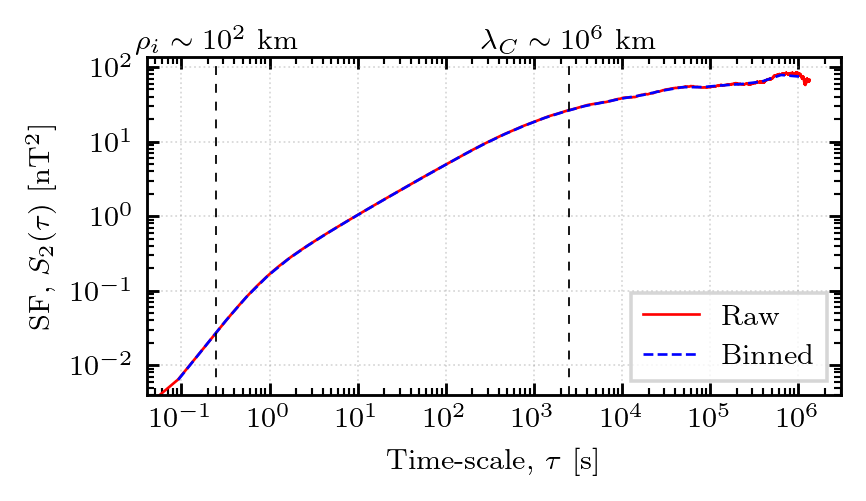

In [27]:

l_array = np.load('l_combined.npy')
sf_array = np.load('sf_combined.npy')

l_b, sf2_b, _ = statistics_base.bin_data(
    l_array, sf_array, bin_func=np.nanmean,
    bin_loc='true_center', log_space=True, min_bin=_L/_N, max_bin=_L/2.,
    num_bins=32)
l_b2 = l_b[np.isfinite(sf2_b)]
sf2_b2 = sf2_b[np.isfinite(sf2_b)]
sf2_b3 = strfn_spectra.interpolate(l_b2, sf2_b2, l_b)

_title = None
plot_sf((l_array, sf_array), (l_b, sf2_b3), _title)

sf_b = (l_b, sf2_b3)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


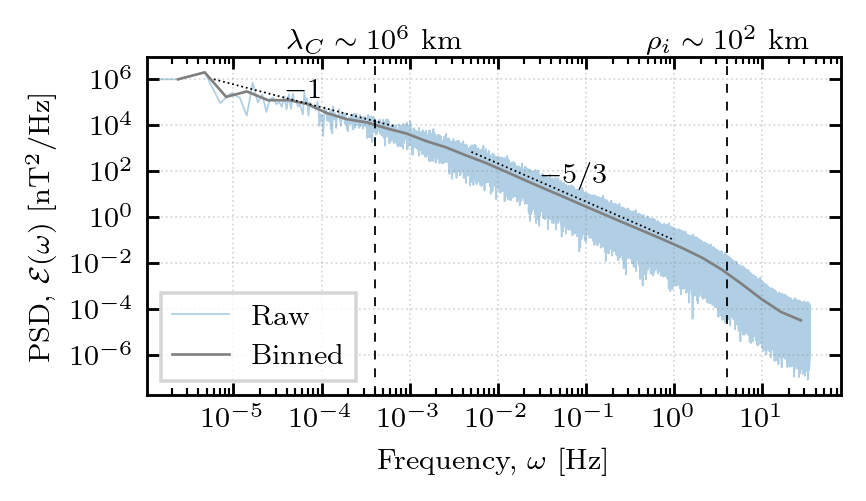

In [28]:

ko = np.load('kmag.npy')
feko = np.load('fek_ii.npy')
kb, fekb, _ = statistics_base.bin_data(
    ko, feko, bin_func=np.nanmean,
    bin_loc='true_center', log_space=True, min_bin=ko[1], max_bin=np.nanmax(ko),
    num_bins=32)
plot_spec((ko, feko), (kb, fekb))


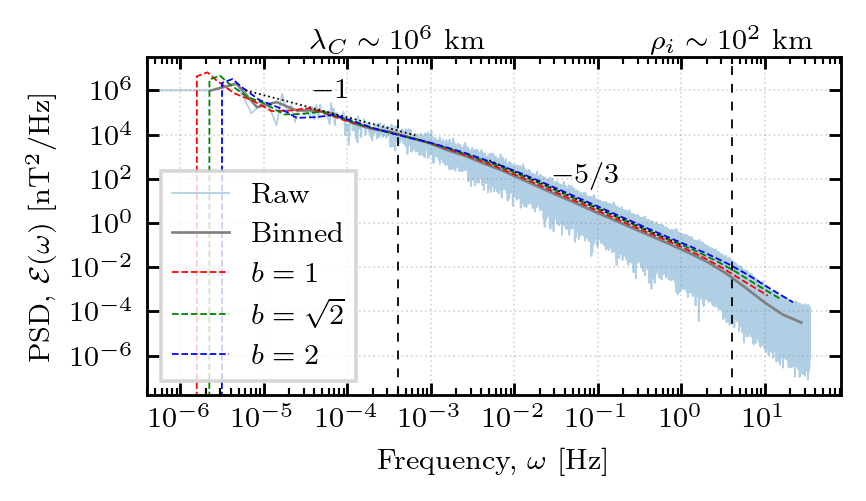

In [29]:

## Get equiv-spectrum
kb1, fekb1 = omni_spectrum(ko, sf_b[0], sf_b[1], phys_dims, grid_dims, 1., 1.)
kb2, fekb2 = omni_spectrum(ko, sf_b[0], sf_b[1], phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
kb3, fekb3 = omni_spectrum(ko, sf_b[0], sf_b[1], phys_dims, grid_dims, 2., 2.)

plot_all_spectra((ko, feko), (kb, fekb), (kb1, fekb1, np.ones_like(fekb1)), (kb2, fekb2, np.ones_like(fekb2)), (kb3, fekb3, np.ones_like(fekb3)), title=None)


/tmp/ipykernel_148508/2317643922.py:2: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(fek), np.log(k))
/tmp/ipykernel_148508/2317643922.py:2: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(fek), np.log(k))
/tmp/ipykernel_148508/2317643922.py:2: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(fek), np.log(k))


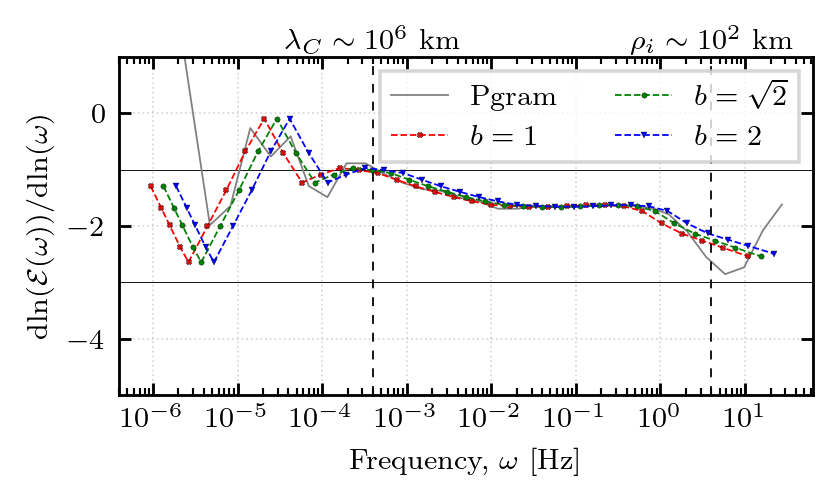

In [30]:

## Estimate powerlaw
a_feko = get_powerlaw(kb, fekb, log_space=False, num_bins=None)
a_fekb1 = get_powerlaw(kb1, fekb1, log_space=True, num_bins=16)
a_fekb2 = get_powerlaw(kb2, fekb2, log_space=True, num_bins=16)
a_fekb3 = get_powerlaw(kb3, fekb3, log_space=True, num_bins=16)

## Plot powerlaw
plot_powerlaw((kb, a_feko), (kb1, a_fekb1), (kb2, a_fekb2), (kb3, a_fekb3), title=_title)


In [31]:

## Get debiasing factors
b_b1 = debias(a_fekb1, 1., len(grid_dims))
b_b2 = debias(a_fekb2, np.sqrt(2.), len(grid_dims))
b_b3 = debias(a_fekb3, 2., len(grid_dims))


In [32]:

def plot_all_spectra_2(raw, binned, fekb1, fekb2, fekb3, title=None):

    grid = '''
AAAAABBB
AAAAACCC
'''
    fig, axs = plt.subplot_mosaic(grid, dpi=512, figsize=(8., 8./3.))

    ax = axs['A']

    ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax.plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax.plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    #ax.legend(frameon=True, fancybox=False, loc='lower left')

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km

    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

    ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

    ax.text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    ax.text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
    ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

    ax.legend(fancybox=False, loc='lower left')

    ax2 = axs['B']
    ax2.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax2.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax2.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax2.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax2.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax2.plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)

    ax2.set_ylim((1e3, 2e6))
    ax2.set_xlim((2e-6, 1e-3))
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax2.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax2.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax2.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax2.xaxis.set_minor_locator(locmin)

    ax2.set_yscale('log')
    ax2.set_xscale('log')
    ax2.yaxis.set_ticks_position('both')
    ax2.xaxis.set_ticks_position('both')
    ax2.tick_params(axis='y', direction='in')
    ax2.tick_params(axis='y', direction='in', which='minor')
    ax2.tick_params(axis='x', direction='in')
    ax2.tick_params(axis='x', direction='in', which='minor')
    ax2.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax2.set_yticklabels([])
    ax2.set_xticklabels([])

    ax3 = axs['C']
    ax3.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax3.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax3.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
    ax3.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    ax3.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    ax3.set_ylim((1e-5, 1e-1))
    ax3.set_xlim((1e0, 22))
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax3.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax3.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax3.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax3.xaxis.set_minor_locator(locmin)

    ax3.set_yscale('log')
    ax3.set_xscale('log')
    ax3.yaxis.set_ticks_position('both')
    ax3.xaxis.set_ticks_position('both')
    ax3.tick_params(axis='y', direction='in')
    ax3.tick_params(axis='y', direction='in', which='minor')
    ax3.tick_params(axis='x', direction='in')
    ax3.tick_params(axis='x', direction='in', which='minor')
    ax3.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax3.set_yticklabels([])
    ax3.set_xticklabels([])

    ax2.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    #ax2.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    ax3.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    #ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    import matplotlib.patches as patches
    rect2 = patches.Rectangle((2e-6, 1e3), 1e-3, 2e6, linewidth=0.25, edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect2)
    rect3 = patches.Rectangle((1e0, 1e-5), 22, 1e-1, linewidth=0.25, edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect3)

    ax.text(0.98, 0.98, r'(a)', transform=ax.transAxes, ha='right', va='top')
    ax2.text(0.98, 0.98, r'(b)', transform=ax2.transAxes, ha='right', va='top')
    ax3.text(0.98, 0.98, r'(c)', transform=ax3.transAxes, ha='right', va='top')

    fig.savefig('large_SW_b.pdf', transparent=True, bbox_inches='tight', pad_inches=0)

## Plot spectra
#plot_all_spectra_2((ko, feko), (kb, fekb), (kb1[2:], fekb1[2:], b_b1[2:]), (kb2[2:], fekb2[2:], b_b2[2:]), (kb3[2:], fekb3[2:], b_b3[2:]), title=None)


In [33]:

# plot_all_spectra_2((ko, feko), (kb, fekb), (kb1[2:], fekb1[2:], np.ones_like(fekb1)[2:]), (kb2[2:], fekb2[2:], np.ones_like(fekb2)[2:]), (kb3[2:], fekb3[2:], np.ones_like(fekb3)[2:]), title=None)


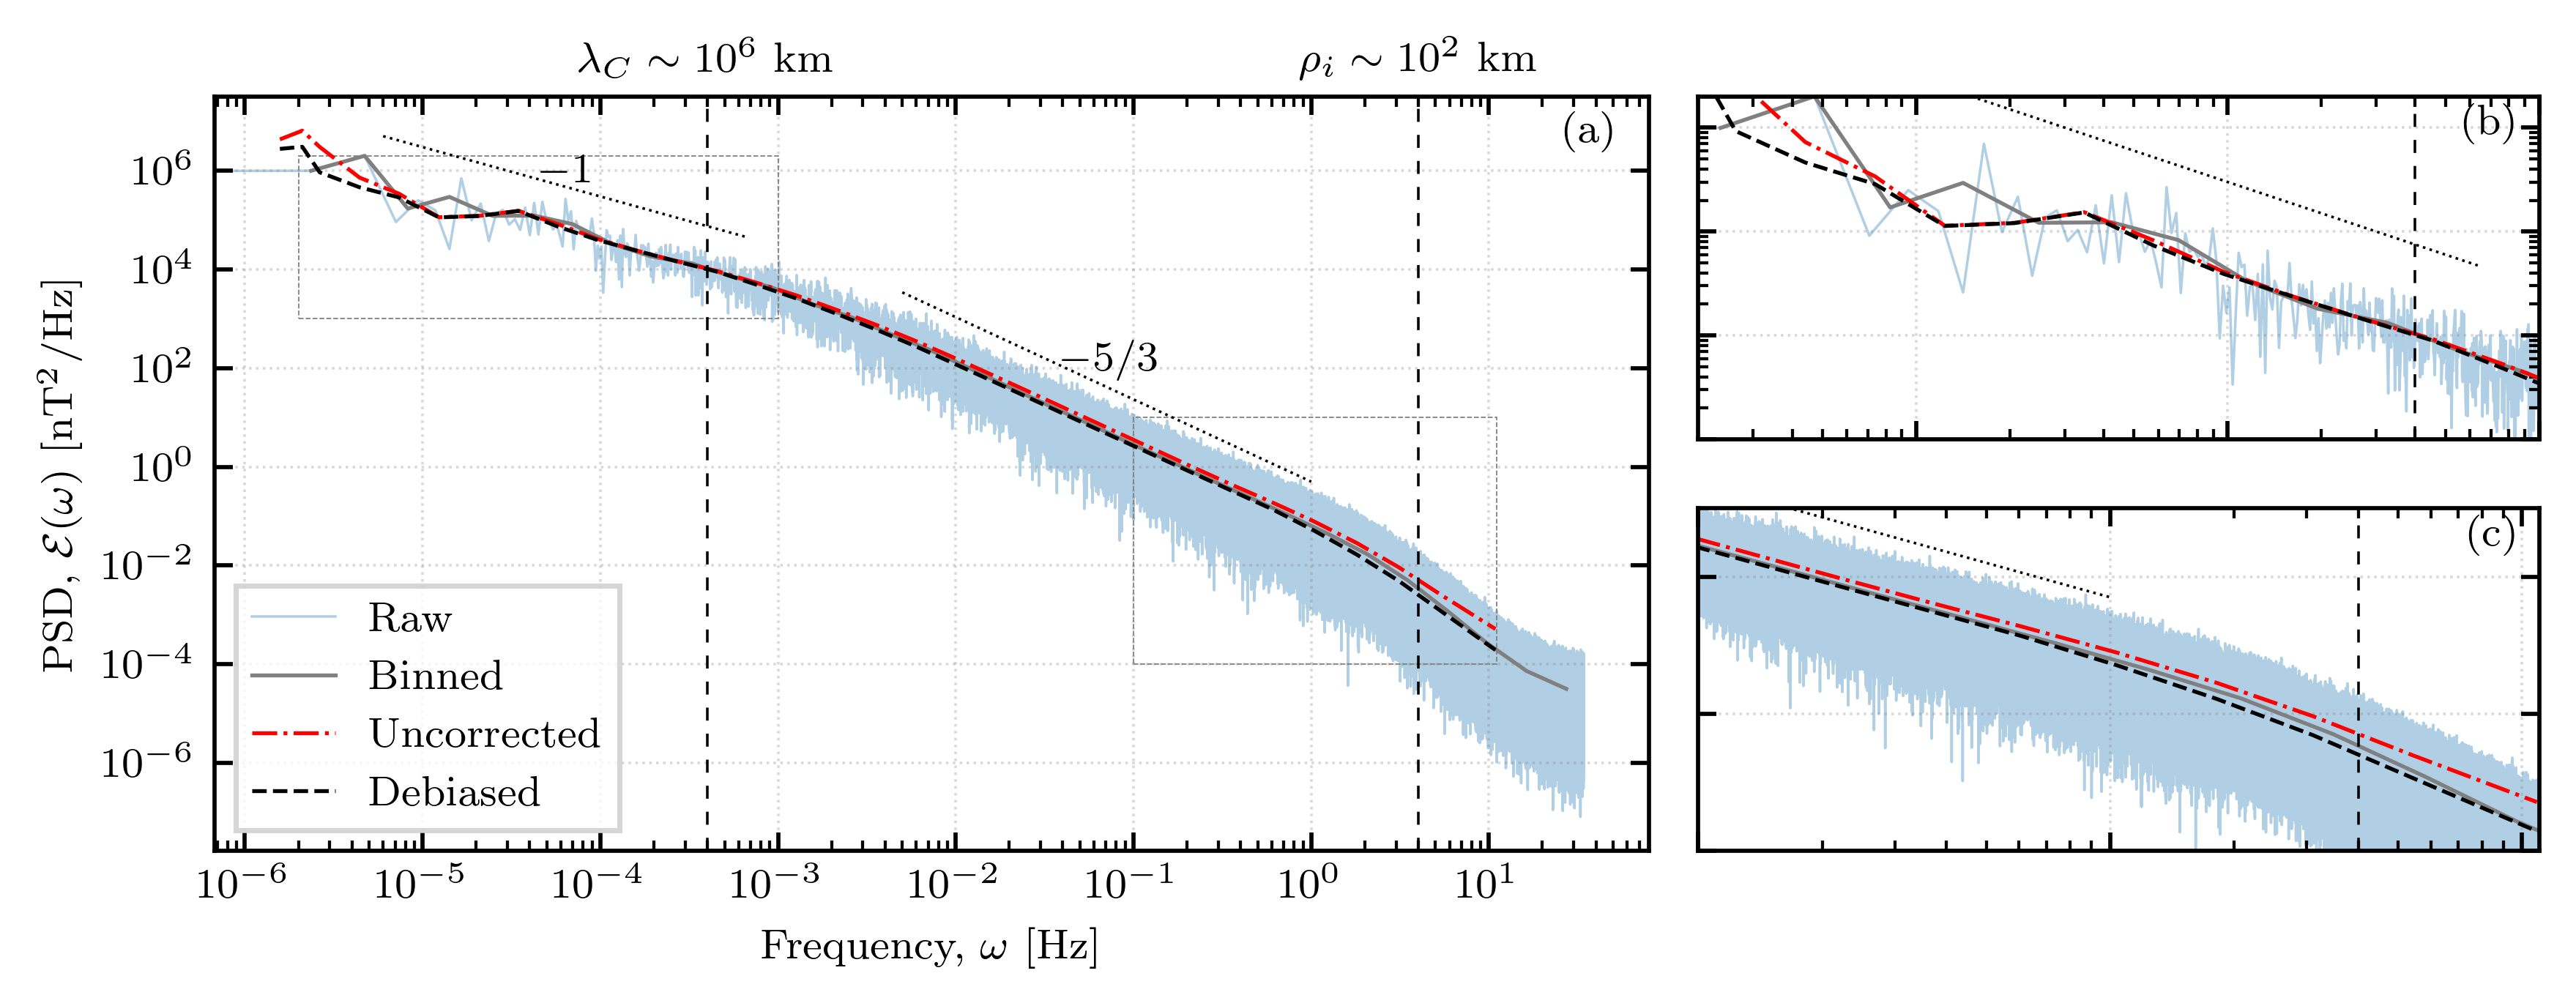

In [34]:

def plot_all_spectra_3(raw, binned, fekb1, title=None):

    grid = '''
AAAAABBB
AAAAACCC
'''
    fig, axs = plt.subplot_mosaic(grid, dpi=512, figsize=(8., 8./3.))

    ax = axs['A']

    ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=1, label='Binned', color='gray')

    ax.plot(fekb1[0], fekb1[1], color='red', linestyle='-.', linewidth=0.75, label=r'Uncorrected', zorder=2)
    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='black', linestyle='--', linewidth=0.75, label=r'Debiased', zorder=3)
    #ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    #ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax.plot(kp1, 3e1*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax.plot(kp53, 5e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    #ax.legend(frameon=True, fancybox=False, loc='lower left')

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km

    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

    ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

    ax.text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    ax.text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
    ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

    ax.legend(fancybox=False, loc='lower left')

    ax2 = axs['B']
    ax2.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax2.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax2.plot(fekb1[0], fekb1[1], color='red', linestyle='-.', linewidth=0.75, label=r'Uncorrected')
    ax2.plot(fekb1[0], fekb1[1]/fekb1[2], color='black', linestyle='--', linewidth=0.75, label=r'Debiased')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax2.plot(kp1, 3e1*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)

    ax2.set_ylim((1e3, 2e6))
    ax2.set_xlim((2e-6, 1e-3))
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax2.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax2.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax2.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax2.xaxis.set_minor_locator(locmin)

    ax2.set_yscale('log')
    ax2.set_xscale('log')
    ax2.yaxis.set_ticks_position('both')
    ax2.xaxis.set_ticks_position('both')
    ax2.tick_params(axis='y', direction='in')
    ax2.tick_params(axis='y', direction='in', which='minor')
    ax2.tick_params(axis='x', direction='in')
    ax2.tick_params(axis='x', direction='in', which='minor')
    ax2.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax2.set_yticklabels([])
    ax2.set_xticklabels([])

    ax3 = axs['C']
    ax3.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax3.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax3.plot(fekb1[0], fekb1[1], color='red', linestyle='-.', linewidth=0.75, label=r'Uncorrected')
    ax3.plot(fekb1[0], fekb1[1]/fekb1[2], color='black', linestyle='--', linewidth=0.75, label=r'Debiased')

    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax3.plot(kp53, 5e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    ax3.set_ylim((1e-4, 1e1))
    ax3.set_xlim((1e-1, 11))
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax3.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax3.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax3.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax3.xaxis.set_minor_locator(locmin)

    ax3.set_yscale('log')
    ax3.set_xscale('log')
    ax3.yaxis.set_ticks_position('both')
    ax3.xaxis.set_ticks_position('both')
    ax3.tick_params(axis='y', direction='in')
    ax3.tick_params(axis='y', direction='in', which='minor')
    ax3.tick_params(axis='x', direction='in')
    ax3.tick_params(axis='x', direction='in', which='minor')
    ax3.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax3.set_yticklabels([])
    ax3.set_xticklabels([])

    ax2.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    #ax2.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    ax3.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    #ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    import matplotlib.patches as patches
    rect2 = patches.Rectangle((2e-6, 1e3), 1e-3, 2e6, linewidth=0.25, edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect2)
    rect3 = patches.Rectangle((1e-1, 1e-4), 11, 1e1, linewidth=0.25, edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect3)

    ax.text(0.98, 0.98, r'(a)', transform=ax.transAxes, ha='right', va='top')
    ax2.text(0.98, 0.98, r'(b)', transform=ax2.transAxes, ha='right', va='top')
    ax3.text(0.98, 0.98, r'(c)', transform=ax3.transAxes, ha='right', va='top')

    fig.savefig('large_SW.pdf', transparent=True, bbox_inches='tight', pad_inches=0)

## Plot spectra
plot_all_spectra_3((ko, feko), (kb, fekb), (kb1[2:], fekb1[2:], b_b1[2:]), title=None)


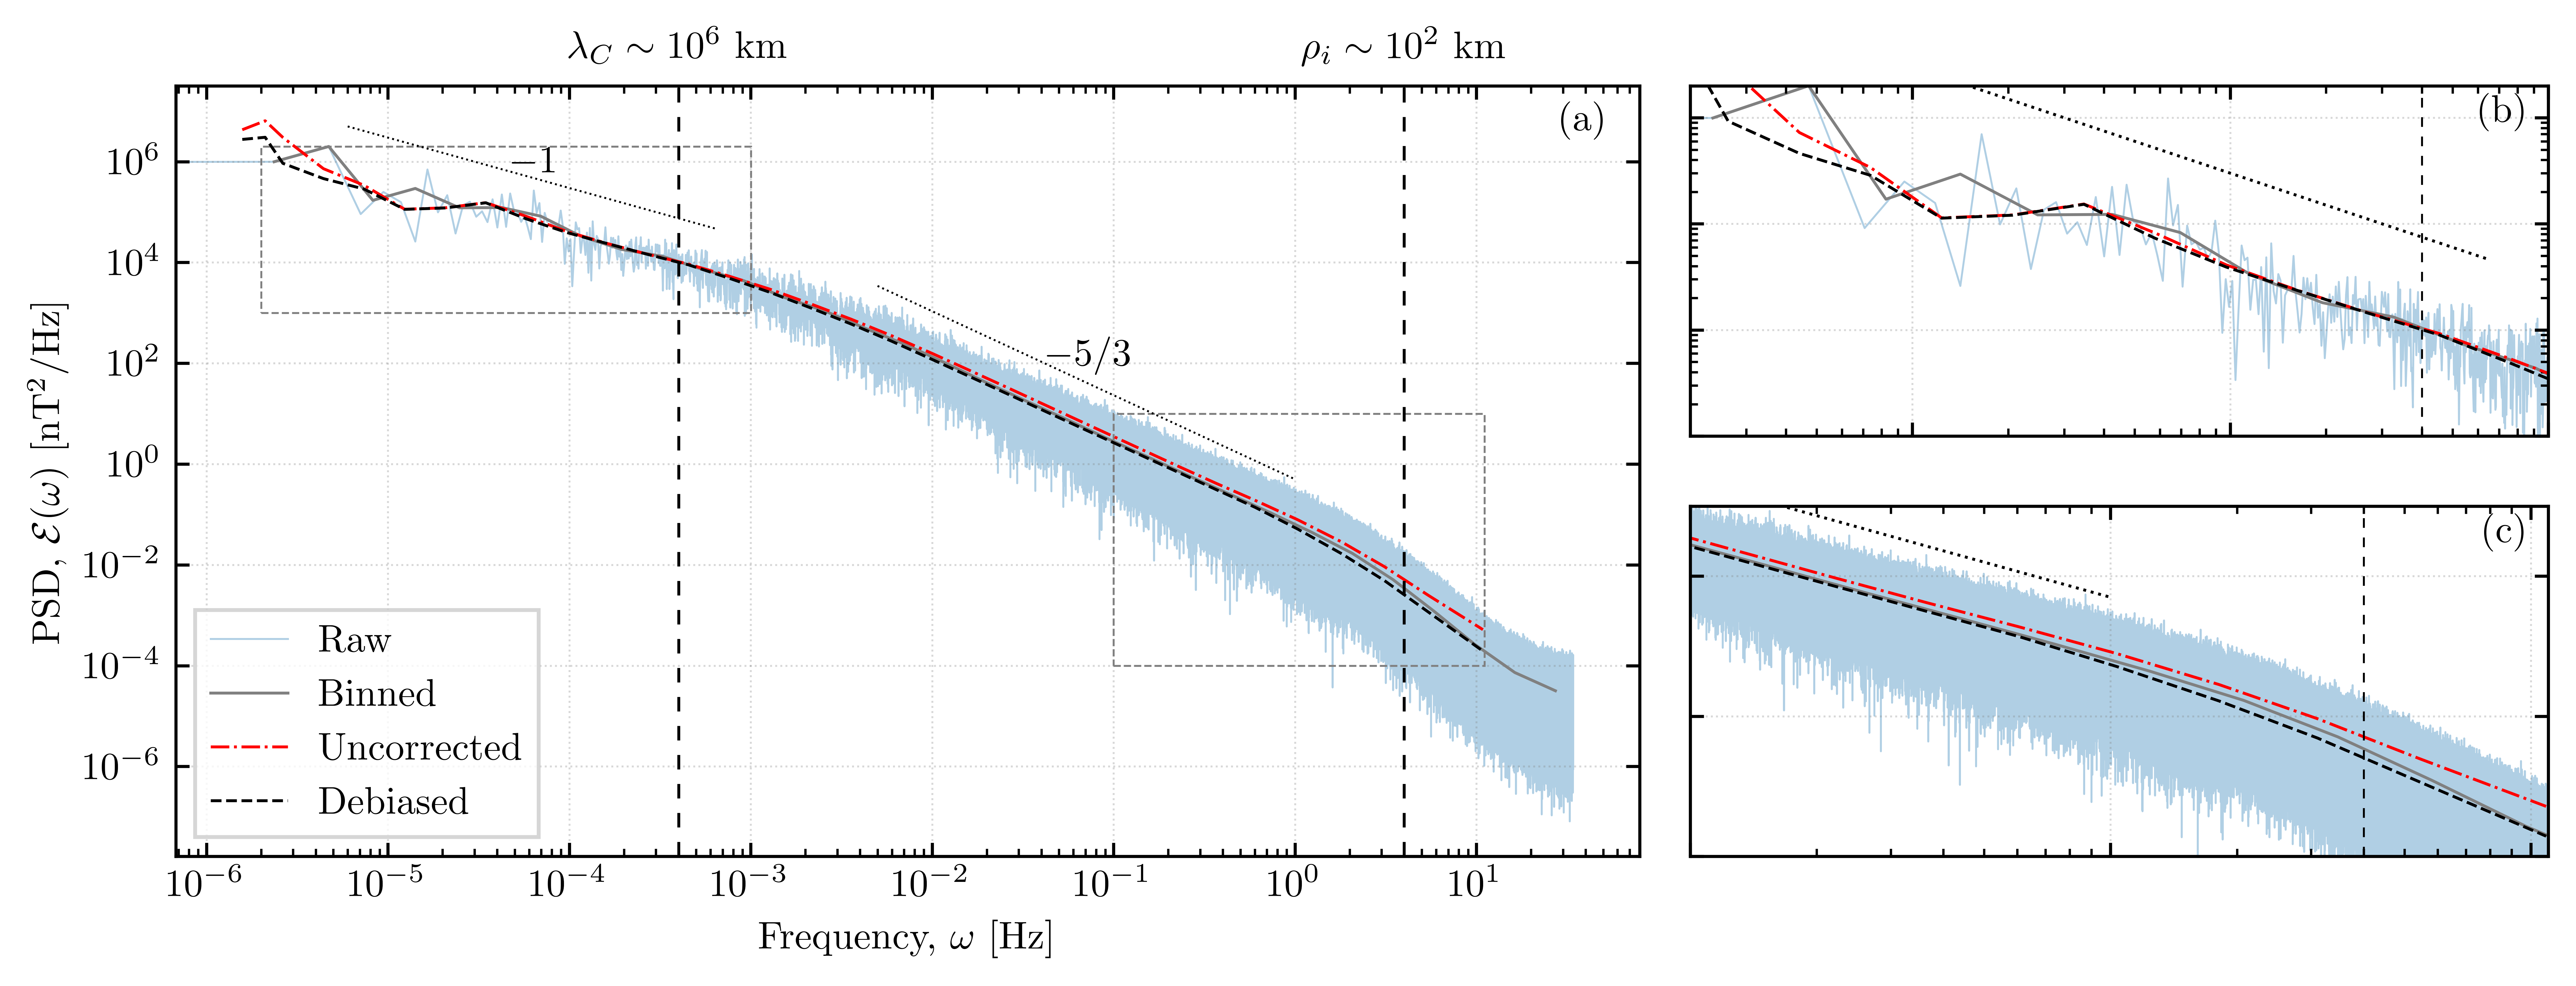

In [18]:

def plot_all_spectra_rotated(raw, binned, fekb1, title=None):

    grid = '''
AAAAABBB
AAAAACCC
'''
    fig, axs = plt.subplot_mosaic(grid, dpi=1024, figsize=(11., 11./3.))

    ax = axs['A']

    ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax.plot(fekb1[0], fekb1[1], color='red', linestyle='-.', linewidth=0.75, label=r'Uncorrected')
    ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='black', linestyle='--', linewidth=0.75, label=r'Debiased')
    #ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
    #ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax.plot(kp1, 3e1*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax.plot(kp53, 5e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    #ax.legend(frameon=True, fancybox=False, loc='lower left')

    U = 400. #km/s
    lc = 1e6 #km
    ri = 1e2 #km
    lt = 3225. #km
    re = 1e0 #km

    props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
    ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.75)
    ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

    ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.75)
    ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

    ax.text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
    ax.text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax.xaxis.set_minor_locator(locmin)

    ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
    ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

    ax.legend(fancybox=False, loc='lower left')

    ax2 = axs['B']
    ax2.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax2.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax2.plot(fekb1[0], fekb1[1], color='red', linestyle='-.', linewidth=0.75, label=r'Uncorrected')
    ax2.plot(fekb1[0], fekb1[1]/fekb1[2], color='black', linestyle='--', linewidth=0.75, label=r'Debiased')

    kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
    ax2.plot(kp1, 3e1*kp1**(-1.), color='black', linestyle=':', linewidth=0.75)

    ax2.set_ylim((1e3, 2e6))
    ax2.set_xlim((2e-6, 1e-3))
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax2.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax2.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax2.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax2.xaxis.set_minor_locator(locmin)

    ax2.set_yscale('log')
    ax2.set_xscale('log')
    ax2.yaxis.set_ticks_position('both')
    ax2.xaxis.set_ticks_position('both')
    ax2.tick_params(axis='y', direction='in')
    ax2.tick_params(axis='y', direction='in', which='minor')
    ax2.tick_params(axis='x', direction='in')
    ax2.tick_params(axis='x', direction='in', which='minor')
    ax2.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax2.set_yticklabels([])
    ax2.set_xticklabels([])

    ax3 = axs['C']
    ax3.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
    ax3.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

    ax3.plot(fekb1[0], fekb1[1], color='red', linestyle='-.', linewidth=0.75, label=r'Uncorrected')
    ax3.plot(fekb1[0], fekb1[1]/fekb1[2], color='black', linestyle='--', linewidth=0.75, label=r'Debiased')

    kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
    ax3.plot(kp53, 5e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.75)

    ax3.set_ylim((1e-4, 1e1))
    ax3.set_xlim((1e-1, 11))
    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax3.yaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax3.yaxis.set_minor_locator(locmin)

    locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
    ax3.xaxis.set_major_locator(locmaj)
    locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
    ax3.xaxis.set_minor_locator(locmin)

    ax3.set_yscale('log')
    ax3.set_xscale('log')
    ax3.yaxis.set_ticks_position('both')
    ax3.xaxis.set_ticks_position('both')
    ax3.tick_params(axis='y', direction='in')
    ax3.tick_params(axis='y', direction='in', which='minor')
    ax3.tick_params(axis='x', direction='in')
    ax3.tick_params(axis='x', direction='in', which='minor')
    ax3.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax3.set_yticklabels([])
    ax3.set_xticklabels([])

    ax2.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    #ax2.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    ax3.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
    #ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

    import matplotlib.patches as patches
    rect2 = patches.Rectangle((2e-6, 1e3), 1e-3, 2e6, linewidth=0.5, edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect2)
    rect3 = patches.Rectangle((1e-1, 1e-4), 11, 1e1, linewidth=0.5, edgecolor='gray', facecolor='none', linestyle='--')
    ax.add_patch(rect3)

    ax.text(0.98, 0.98, r'(a)', transform=ax.transAxes, ha='right', va='top')
    ax2.text(0.98, 0.98, r'(b)', transform=ax2.transAxes, ha='right', va='top')
    ax3.text(0.98, 0.98, r'(c)', transform=ax3.transAxes, ha='right', va='top')

    fig.savefig('large_SW_landscape.png', bbox_inches='tight', pad_inches=0)

## Plot spectra
#plot_all_spectra_rotated((ko, feko), (kb, fekb), (kb1[2:], fekb1[2:], b_b1[2:]), title=None)


In [19]:

# def plot_all_spectra_2(raw, binned, fekb1, fekb2, fekb3, title=None):

#     fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

#     ax.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
#     ax.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

#     ax.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
#     ax.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
#     ax.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

#     kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
#     ax.plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)
#     kp53 = np.exp(np.linspace(np.log(5e-3), np.log(1e0), 50))
#     ax.plot(kp53, 1e-1*kp53**(-5./3.), color='black', linestyle=':', linewidth=0.5)

#     ax.set_yscale('log')
#     ax.set_xscale('log')
#     ax.yaxis.set_ticks_position('both')
#     ax.xaxis.set_ticks_position('both')
#     ax.tick_params(axis='y', direction='in')
#     ax.tick_params(axis='y', direction='in', which='minor')
#     ax.tick_params(axis='x', direction='in')
#     ax.tick_params(axis='x', direction='in', which='minor')
#     ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

#     #ax.legend(frameon=True, fancybox=False, loc='lower left')

#     U = 400. #km/s
#     lc = 1e6 #km
#     ri = 1e2 #km
#     lt = 3225. #km
#     re = 1e0 #km

#     props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
#     ax.axvline(U/lc, color='black', linestyle=(0,(5,5)), linewidth=0.5)
#     ax.text(U/lc, 1.05, r'$\lambda_{C} \sim 10^6$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

#     #ax.axvline(U/lt, color='black', linestyle=(0,(5,5)), linewidth=0.5)

#     ax.axvline(U/ri, color='black', linestyle=(0,(5,5)), linewidth=0.5)
#     ax.text(U/ri, 1.05, r'$\rho_{i} \sim 10^2$ km', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

#     #ax.axvline(U/re, color='black', linestyle=(0,(5,5)), linewidth=0.25)

#     ax.text(kp1[len(kp1)//2], 0.9, r'$-1$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')
#     ax.text(kp53[len(kp53)//2], 0.65, r'$-5/3$', color='black', transform=ax.get_xaxis_transform(), bbox=props, ha='center', va='center')

#     locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
#     ax.yaxis.set_major_locator(locmaj)
#     locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
#     ax.yaxis.set_minor_locator(locmin)

#     locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
#     ax.xaxis.set_major_locator(locmaj)
#     locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
#     ax.xaxis.set_minor_locator(locmin)

#     ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
#     ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

#     #ax2 = fig.add_axes([1.001, 0.45, 0.4, 0.4])
#     ax2 = fig.add_axes([0.15, 0.175, 0.375, 0.375])

#     ax2.plot(raw[0], raw[1], linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
#     ax2.plot(binned[0], binned[1], linewidth=0.75, zorder=0, label='Binned', color='gray')

#     ax2.plot(fekb1[0], fekb1[1]/fekb1[2], color='red', linestyle='--', linewidth=0.5, label=r'$b=1$')
#     ax2.plot(fekb2[0], fekb2[1]/fekb2[2], color='green', linestyle='--', linewidth=0.5, label=r'$b=\sqrt{2}$')
#     ax2.plot(fekb3[0], fekb3[1]/fekb3[2], color='blue', linestyle='--', linewidth=0.5, label=r'$b=2$')

#     kp1 = np.exp(np.linspace(np.log(6e-6), np.log(6.5e-4), 50))
#     ax2.plot(kp1, 6e0*kp1**(-1.), color='black', linestyle=':', linewidth=0.5)

#     ax2.set_ylim((1e3, 1e7))
#     ax2.set_xlim((1e-6, 1e-3))
#     locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
#     ax2.yaxis.set_major_locator(locmaj)
#     locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
#     ax2.yaxis.set_minor_locator(locmin)

#     locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
#     ax2.xaxis.set_major_locator(locmaj)
#     locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
#     ax2.xaxis.set_minor_locator(locmin)

#     ax2.set_yscale('log')
#     ax2.set_xscale('log')
#     ax2.yaxis.set_ticks_position('both')
#     ax2.xaxis.set_ticks_position('both')
#     ax2.tick_params(axis='y', direction='in')
#     ax2.tick_params(axis='y', direction='in', which='minor')
#     ax2.tick_params(axis='x', direction='in')
#     ax2.tick_params(axis='x', direction='in', which='minor')
#     ax2.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

#     ax2.set_yticklabels([])
#     ax2.set_xticklabels([])

#     #fig.align_ylabels()

#     fig.subplots_adjust(wspace=0.01)

# ## Plot spectra
# plot_all_spectra_2((ko, feko), (kb, fekb), (kb1[2:], fekb1[2:], b_b1[2:]), (kb2[2:], fekb2[2:], b_b2[2:]), (kb3[2:], fekb3[2:], b_b3[2:]), title=None)

